# 01 — Clustering de Perfil de Carreira
**Responsável**: R2 (Remoto)

**Objetivo**: Agrupar artistas em perfis de carreira via K-Means, para uso como **feature** no modelo supervisionado (02).

**Ordem de execução**: depende só do 00 (`artist_country_features.parquet`, já deduplicado). Roda **antes** do 02, que consome `cluster_labels.csv` gerado aqui.

**Guiding Questions**: A (Quem é esse artista?)

## Por que as features de tendência/recência (`trend_30d`, `trend_90d`, `avg_rank`, `best_rank`, `days_since_last_seen`) ficam de fora

O notebook 02 define `recommend_label` com base em recência + percentil de streams. Se o cluster deste notebook usar as mesmas colunas de recência/rank, o perfil resultante fica quase uma restatement da regra do target — alimentar esse perfil de volta no Random Forest do 02 reintroduziria vazamento.

Por isso este notebook usa só **forma estrutural de carreira** (catálogo, volume histórico, concentração, consistência de entradas) — sinais que descrevem "que tipo de artista é esse" sem reconstruir "está em alta agora". Uma coluna `trend_status` **apenas informativa** (não usada como feature do RF) é calculada no fim para não perder essa leitura de trajetória para dashboards/EDA.

In [26]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_parquet('../data/processed/artist_country_features.parquet')
print(f'Shape: {df.shape}')

Shape: (13120, 20)


## 1. Selecionar Features para Clustering (sem vazamento)

In [27]:
# Features de FORMA estrutural de carreira — nada de trend/recência/rank
# (essas ficam de fora porque são a base da regra de recommend_label no 02)
raw_features = ['total_tracks', 'total_streams', 'days_on_chart_total', 'stream_concentration', 'entry_count']
print('Nulos:', df[raw_features].isnull().sum().to_dict(), '-> nenhum, não precisa dropar/imputar linha')

df_cluster = df.copy()
X = df_cluster[raw_features].copy()
# total_streams e total_tracks são muito assimétricos (cauda longa) -> log1p
X['log_total_streams'] = np.log1p(X['total_streams'])
X['log_total_tracks'] = np.log1p(X['total_tracks'])
X = X.drop(columns=['total_streams', 'total_tracks'])
cluster_features = X.columns.tolist()
print('Features usadas no cluster:', cluster_features)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'Dados para clustering: {X_scaled.shape}')

Nulos: {'total_tracks': 0, 'total_streams': 0, 'days_on_chart_total': 0, 'stream_concentration': 0, 'entry_count': 0} -> nenhum, não precisa dropar/imputar linha
Features usadas no cluster: ['days_on_chart_total', 'stream_concentration', 'entry_count', 'log_total_streams', 'log_total_tracks']
Dados para clustering: (13120, 5)


## 2. Elbow Method + Silhouette Score

k=2: inertia=36340, silhouette=0.5606
k=3: inertia=26330, silhouette=0.4669
k=4: inertia=21528, silhouette=0.3771
k=5: inertia=17789, silhouette=0.3918
k=6: inertia=14996, silhouette=0.3985
k=7: inertia=12791, silhouette=0.4199
k=8: inertia=11323, silhouette=0.4034


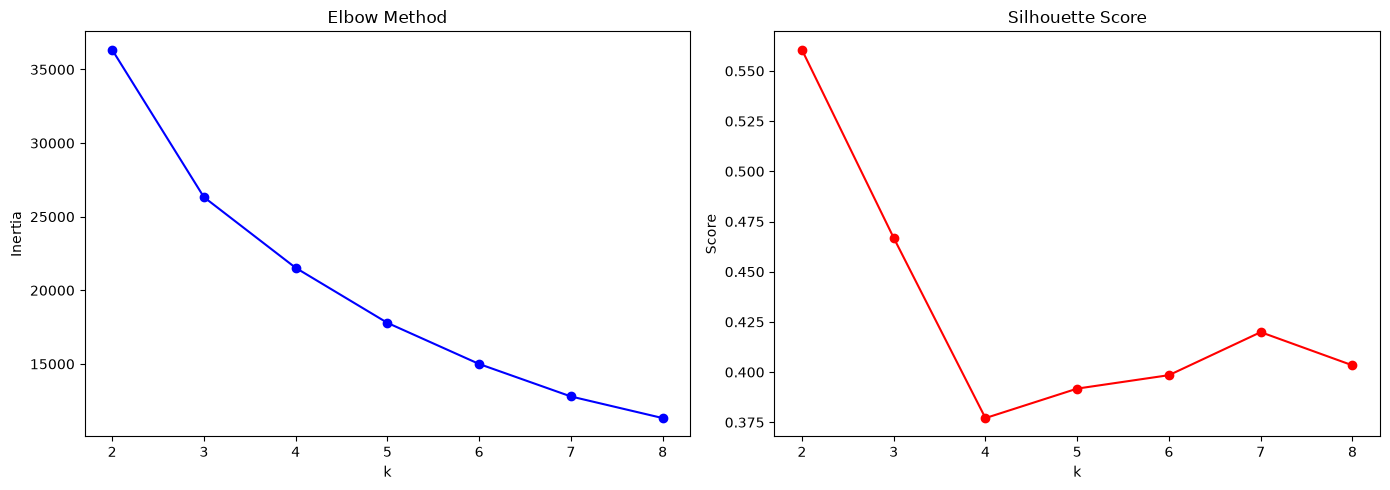

In [28]:
K_range = range(2, 9)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels, sample_size=min(10000, len(X_scaled)), random_state=42)
    silhouettes.append(sil)
    print(f'k={k}: inertia={km.inertia_:.0f}, silhouette={sil:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_range), inertias, 'bo-')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[1].plot(list(K_range), silhouettes, 'ro-')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Score')
plt.tight_layout()
plt.savefig('../docs/clustering_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

**k=2 tem o maior silhouette, mas é uma divisão trivial (basicamente "grande vs. pequeno").** Entre as opções com granularidade útil para o negócio, k=5 tem o segundo melhor silhouette local e bate com os 5 perfis que o time já usa na narrativa (README) — por isso fica como escolha final abaixo.

## 3. Treinar K-Means Final

In [29]:
BEST_K = 5

km_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=20, max_iter=500)
df_cluster['cluster'] = km_final.fit_predict(X_scaled)
print(f'Silhouette final: {silhouette_score(X_scaled, df_cluster["cluster"], sample_size=min(10000, len(X_scaled)), random_state=42):.4f}')
print(f'\nDistribuição dos clusters:')
print(df_cluster['cluster'].value_counts().sort_index())

Silhouette final: 0.3918

Distribuição dos clusters:
cluster
0    5312
1    3736
2    1073
3    2814
4     185
Name: count, dtype: int64


## 4. Interpretar Clusters

         total_tracks  total_streams  days_on_chart_total  \
cluster                                                     
0                1.18   6.964090e+05                 8.98   
1                1.80   3.200396e+07               157.81   
2               27.85   4.731349e+08               694.79   
3                6.43   6.084185e+07               168.41   
4              122.49   2.307768e+09               958.22   

         stream_concentration  entry_count  n_artistas  log_total_streams  \
cluster                                                                     
0                        0.96         1.11        5312              12.79   
1                        0.95         1.53        3736              16.62   
2                        0.36        22.66        1073              19.53   
3                        0.53          5.3        2814              16.87   
4                        0.15       100.96         185              21.01   

         log_total_tracks  
clus

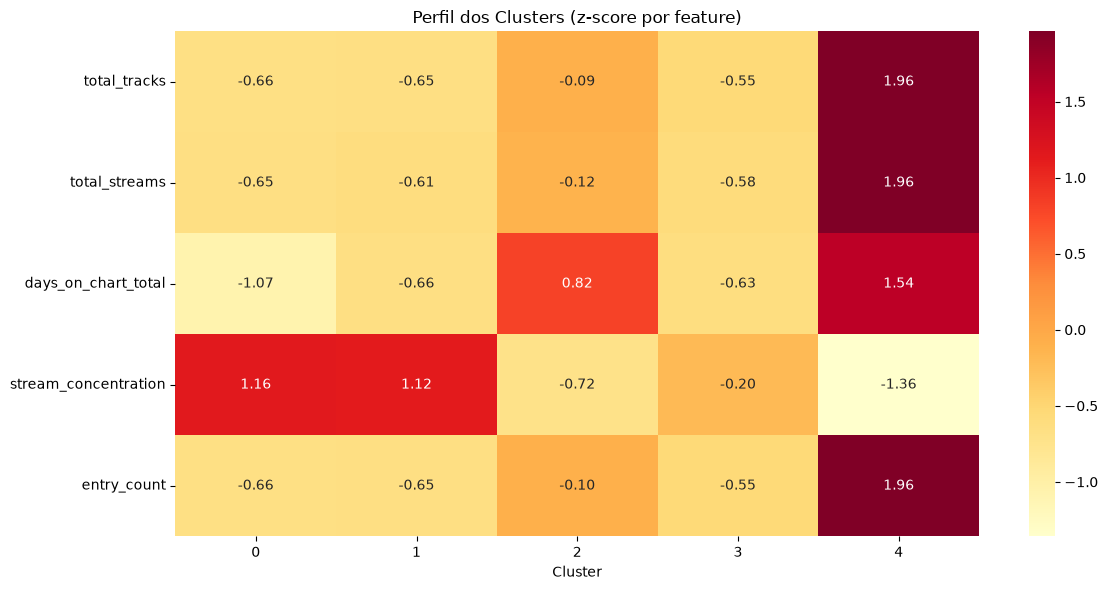

In [30]:
cluster_profiles = df_cluster.groupby('cluster')[raw_features].mean()
cluster_profiles['n_artistas'] = df_cluster['cluster'].value_counts().sort_index()
# precisamos das versoes log (mesma escala usada no clustering) para o scale_score da secao 5
log_means = X[['log_total_streams', 'log_total_tracks']].groupby(df_cluster['cluster']).mean()
cluster_profiles = cluster_profiles.join(log_means)
print(cluster_profiles.round(2))

scaler_vis = StandardScaler()
normalized = pd.DataFrame(
    scaler_vis.fit_transform(cluster_profiles[raw_features]),
    columns=raw_features, index=cluster_profiles.index
)
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(normalized.T, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax)
ax.set_title('Perfil dos Clusters (z-score por feature)')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.savefig('../docs/cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Nomear Clusters (de forma automática, não por ID fixo)

**Cuidado que já nos mordeu uma vez:** o `cluster_id` do KMeans é arbitrário — ele pode mudar entre execuções mesmo com `random_state` fixo, se os dados de entrada mudarem (ex. depois da consolidação de artistas duplicados, os IDs 0-4 já vieram numa ordem diferente da vez anterior, e um mapeamento fixo por ID acabou rotulando Henrique & Juliano e Taylor Swift como "Efêmero Cauda Longa"). Por isso os nomes abaixo são atribuídos **por característica do centróide**, não por número de cluster:

1. Separar clusters "concentrados" (`stream_concentration` alta, ≥ 0.8 — sinal de poucas faixas dominando o streaming) dos "diversificados" (< 0.8).
2. Dentro de cada grupo, ordenar por escala (streams/faixas/dias no chart, combinados em z-score).
3. Diversificados, do maior pro menor: **Veterano Consistente** → **Consolidado** → **Nicho Recorrente**.
4. Concentrados, do maior pro menor: **One-Hit Wonder** → **Efêmero Cauda Longa**.

In [31]:
scale_cols = ['log_total_streams', 'log_total_tracks', 'days_on_chart_total', 'entry_count']
scale_z = (cluster_profiles[scale_cols] - cluster_profiles[scale_cols].mean()) / cluster_profiles[scale_cols].std()
cluster_profiles['scale_score'] = scale_z.mean(axis=1)

is_concentrated = cluster_profiles['stream_concentration'] >= 0.8

diversified = cluster_profiles[~is_concentrated].sort_values('scale_score', ascending=False)
concentrated = cluster_profiles[is_concentrated].sort_values('scale_score', ascending=False)

diversified_names = ['Veterano Consistente', 'Consolidado', 'Nicho Recorrente']
concentrated_names = ['One-Hit Wonder', 'Efemero Cauda Longa']

cluster_names = {}
cluster_names.update(dict(zip(diversified.index, diversified_names[:len(diversified)])))
cluster_names.update(dict(zip(concentrated.index, concentrated_names[:len(concentrated)])))
print('Mapeamento cluster -> perfil (calculado a partir dos centroides desta execução):')
print(cluster_names)

df_cluster['profile'] = df_cluster['cluster'].map(cluster_names)
print(df_cluster['profile'].value_counts())
print()
print(df_cluster[['artist_name','country','cluster','profile']].head(10))

Mapeamento cluster -> perfil (calculado a partir dos centroides desta execução):
{4: 'Veterano Consistente', 2: 'Consolidado', 3: 'Nicho Recorrente', 1: 'One-Hit Wonder', 0: 'Efemero Cauda Longa'}
profile
Efemero Cauda Longa     5312
One-Hit Wonder          3736
Nicho Recorrente        2814
Consolidado             1073
Veterano Consistente     185
Name: count, dtype: int64

        artist_name country  cluster              profile
0             Turbo      us        0  Efemero Cauda Longa
1               EME      br        3     Nicho Recorrente
2         Eric Land      br        2          Consolidado
3  Hernan Sepulveda      mx        1       One-Hit Wonder
4   Victor Cardenas      ar        1       One-Hit Wonder
5   Victor Cardenas      br        3     Nicho Recorrente
6   Victor Cardenas      mx        1       One-Hit Wonder
7   Victor Cardenas      us        0  Efemero Cauda Longa
8      Lana Del Rey      ar        3     Nicho Recorrente
9      Lana Del Rey      br        2       

## 6. Visualizar Clusters (PCA 2D)

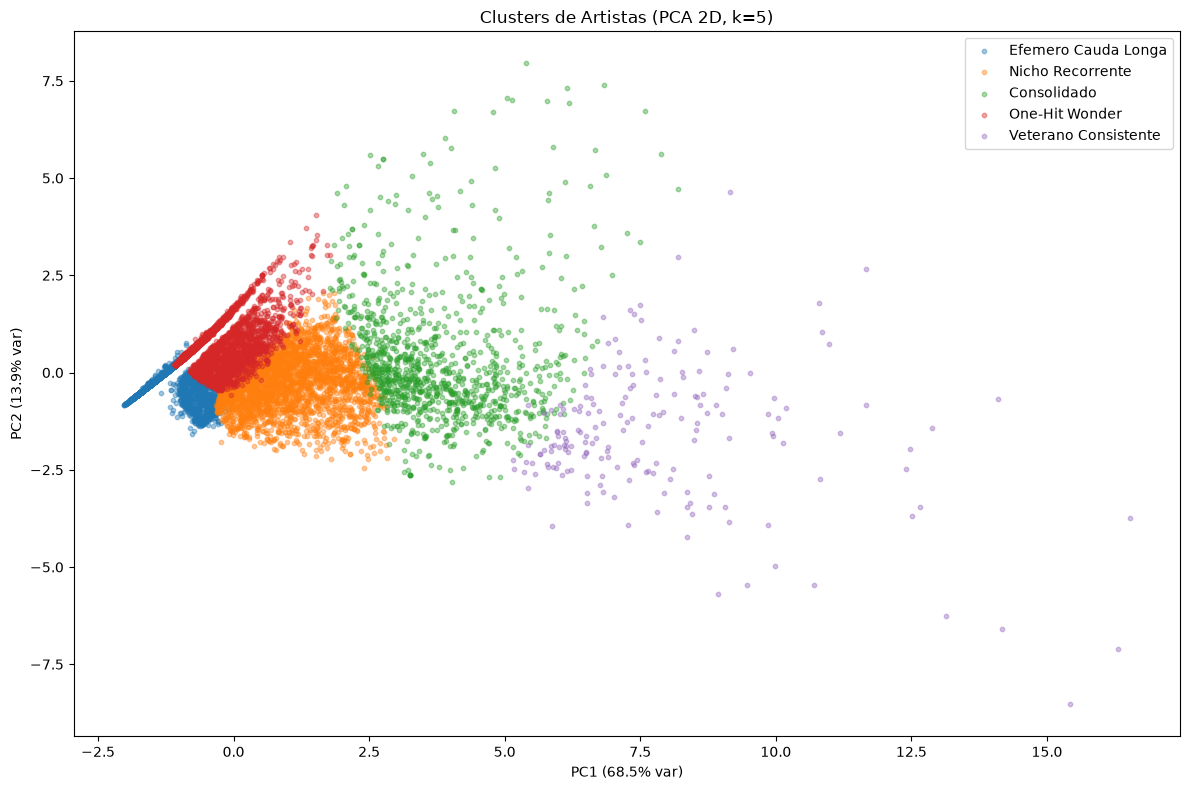

In [32]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df_cluster['pca_1'] = X_pca[:, 0]
df_cluster['pca_2'] = X_pca[:, 1]

fig, ax = plt.subplots(figsize=(12, 8))
for prof in df_cluster['profile'].unique():
    sub = df_cluster[df_cluster['profile'] == prof]
    ax.scatter(sub['pca_1'], sub['pca_2'], label=prof, alpha=0.4, s=10)
ax.set_title(f'Clusters de Artistas (PCA 2D, k={BEST_K})')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
ax.legend()
plt.tight_layout()
plt.savefig('../docs/cluster_pca.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Validar com Exemplos Conhecidos

In [33]:
known_artists = ['Drake', 'Taylor Swift', 'Bad Bunny', 'Billie Eilish', 'Anitta', 'Måneskin',
                  "Guns N' Roses", 'Queen', 'Madonna', 'The Police', 'AC/DC',
                  'The Kid LAROI', 'Benson Boone', 'Teddy Swims', 'sombr']
for name in known_artists:
    match = df_cluster[df_cluster['artist_name'].str.contains(name, case=False, na=False)]
    if len(match) > 0:
        for _, row in match.iterrows():
            print(f"{name} ({row['country']}): cluster={row['cluster']}, profile={row['profile']}")
    else:
        print(f'{name}: NÃO ENCONTRADO')

Drake (mx): cluster=0, profile=Efemero Cauda Longa
Drake (us): cluster=0, profile=Efemero Cauda Longa
Drake (ar): cluster=2, profile=Consolidado
Drake (br): cluster=2, profile=Consolidado
Drake (gb): cluster=4, profile=Veterano Consistente
Drake (mx): cluster=2, profile=Consolidado
Drake (us): cluster=4, profile=Veterano Consistente
Taylor Swift (ar): cluster=4, profile=Veterano Consistente
Taylor Swift (br): cluster=4, profile=Veterano Consistente
Taylor Swift (gb): cluster=4, profile=Veterano Consistente
Taylor Swift (mx): cluster=4, profile=Veterano Consistente
Taylor Swift (us): cluster=4, profile=Veterano Consistente
Bad Bunny (ar): cluster=4, profile=Veterano Consistente
Bad Bunny (br): cluster=3, profile=Nicho Recorrente
Bad Bunny (gb): cluster=2, profile=Consolidado
Bad Bunny (mx): cluster=4, profile=Veterano Consistente
Bad Bunny (us): cluster=4, profile=Veterano Consistente
Billie Eilish (ar): cluster=2, profile=Consolidado
Billie Eilish (br): cluster=2, profile=Consolidado
B

## 7.1 Corrigir viés "fama global vs. atividade recente no chart local"

Reparem acima: **Guns N' Roses**, **Queen**, **Madonna**, **The Police** e **AC/DC** caem em `One-Hit Wonder`/`Efêmero Cauda Longa` em vários países — porque o clustering só enxerga o comportamento de chart *daquele país específico* (catálogo pequeno, streaming concentrado em 1-2 faixas com pico viral). Isso é verdade sobre o comportamento de chart, mas engana quem lê "One-Hit Wonder" como "artista pouco relevante".

**Primeira tentativa (não usada): incluir `monthly_listeners` direto nas features do KMeans.** O silhouette caiu de 0,39 para 0,27 — `monthly_listeners` é global (idêntico nas 5 linhas de país do mesmo artista) e só atrapalha a diferenciação por país.

**Segunda tentativa: override só por percentil de `monthly_listeners` (top ~7% global).** Corrigiu as bandas de catálogo antigo, mas **capturou também estrelas pop atuais** que só ainda não têm catálogo extenso *neste país específico* — The Kid LAROI, Benson Boone, Teddy Swims, sombr entraram como "Legado Global" mesmo sendo artistas novos e em ascensão, o que não faz sentido: fama global alta + catálogo local pequeno também descreve "astro internacional que ainda está conquistando esse mercado", não só "veterano".

**Correção final: adicionar um filtro de "tempo de estrada".** Calculamos `global_first_entry` = a data mais antiga em que o artista apareceu no chart, entre TODOS os países da base (não só o país da linha). Bandas de catálogo (Beatles, AC/DC, Guns N' Roses, The Police) já apareciam no dia 1 dos dados (2017) — sinal de que o catálogo é anterior à janela observada. Astros atuais (Kid LAROI, Benson Boone, Teddy Swims, sombr) só entram no chart a partir de 2019-2025 — sinal de carreira recente. `Legado Global` agora exige **as duas coisas**: fama global alta **e** presença no chart desde o início da janela de dados (antes de 2019).

> Limitação conhecida: não temos o ano real de estreia do artista (só quando ele entrou *neste* chart, que começa em 2017) — um artista de catálogo antigo cuja música só viralizou pela primeira vez em, digamos, 2023 ficaria de fora dessa regra por engano. É um tradeoff aceitável: prioriza não confundir "consagrado" com "em ascensão", que era o erro mais visível.

In [34]:
global_first_entry = df_cluster.groupby('artist_uri')['first_entry_date'].transform('min')
is_legacy_vintage = global_first_entry < pd.Timestamp('2019-01-01')

ml_pct = df_cluster['monthly_listeners'].rank(pct=True)
override = (
    (ml_pct >= 0.93)
    & df_cluster['profile'].isin(['One-Hit Wonder', 'Efemero Cauda Longa'])
    & is_legacy_vintage
)
print(f'Linhas reclassificadas para Legado Global: {override.sum()} ({100*override.mean():.2f}% do total)')

df_cluster.loc[override, 'profile'] = 'Legado Global'
print()
print(df_cluster['profile'].value_counts())

print()
print('Revalidando os mesmos artistas conhecidos:')
for name in known_artists:
    match = df_cluster[df_cluster['artist_name'].str.contains(name, case=False, na=False)]
    for _, row in match.iterrows():
        print(f"{name} ({row['country']}): profile={row['profile']}")

Linhas reclassificadas para Legado Global: 108 (0.82% do total)

profile
Efemero Cauda Longa     5255
One-Hit Wonder          3685
Nicho Recorrente        2814
Consolidado             1073
Veterano Consistente     185
Legado Global            108
Name: count, dtype: int64

Revalidando os mesmos artistas conhecidos:
Drake (mx): profile=Efemero Cauda Longa
Drake (us): profile=Efemero Cauda Longa
Drake (ar): profile=Consolidado
Drake (br): profile=Consolidado
Drake (gb): profile=Veterano Consistente
Drake (mx): profile=Consolidado
Drake (us): profile=Veterano Consistente
Taylor Swift (ar): profile=Veterano Consistente
Taylor Swift (br): profile=Veterano Consistente
Taylor Swift (gb): profile=Veterano Consistente
Taylor Swift (mx): profile=Veterano Consistente
Taylor Swift (us): profile=Veterano Consistente
Bad Bunny (ar): profile=Veterano Consistente
Bad Bunny (br): profile=Nicho Recorrente
Bad Bunny (gb): profile=Consolidado
Bad Bunny (mx): profile=Veterano Consistente
Bad Bunny (us): pr

## 8. `trend_status` — leitura de tendência (apenas informativo, NÃO entra no RF)

Mantém a leitura de trajetória (Em Ascensão / Estável / Em Declínio / Possível Retomada / Inativo) que o README original queria, só que como coluna **descritiva** separada do `profile` estrutural — para dashboards e para o produtor de eventos lerem junto com o score, sem ser usada como feature do modelo supervisionado (evitaria o mesmo vazamento que motivou excluir essas colunas no 02).

In [35]:
def trend_status(row):
    recent = row['days_since_last_seen'] <= 90
    t90 = row['trend_90d']
    if recent and pd.notna(t90) and t90 > 0.2:
        return 'Em Ascensao'
    if recent and pd.notna(t90) and t90 < -0.2:
        return 'Em Declinio'
    if recent:
        return 'Estavel'
    if row['days_since_last_seen'] <= 365 and pd.notna(t90) and t90 > 0:
        return 'Possivel Retomada'
    return 'Inativo'

df_cluster['trend_status'] = df_cluster.apply(trend_status, axis=1)
print(df_cluster['trend_status'].value_counts())

trend_status
Inativo        11392
Em Ascensao      902
Em Declinio      584
Estavel          242
Name: count, dtype: int64


## 9. Salvar Labels

In [36]:
result = df_cluster[['artist_uri', 'artist_name', 'country', 'cluster', 'profile', 'trend_status']]
result.to_csv('../data/processed/cluster_labels.csv', index=False)
print(f'Cluster labels salvos: {len(result)} artistas x país')
result.head()

Cluster labels salvos: 13120 artistas x país


,artist_uri,artist_name,country,cluster,profile,trend_status
0,spotify:artist:002HSjuWsGMinkXTa7JcRp,Turbo,us,0,Efemero Cauda Longa,Inativo
1,spotify:artist:004h2uqVUpmOuz4oY6aTqw,EME,br,3,Nicho Recorrente,Inativo
2,spotify:artist:007FXgr0jLBJxhPJjacXQH,Eric Land,br,2,Consolidado,Inativo
3,spotify:artist:00CEIWvwRzWGVahslNZW0Z,Hernan Sepulveda,mx,1,One-Hit Wonder,Inativo
4,spotify:artist:00CMSJdbf36zOzKB3z8JrR,Victor Cardenas,ar,1,One-Hit Wonder,Inativo
